# 5. Phase covariance

**Note:**
- The numbers $a_1$, $a_2$ come from adjusting the function $\text{Airy}_1(x)$ to two points: $(0, Airy_1(0))$ and $(0.5, Airy_1(0.5))$. 
- That must be done for each time instant, therefore $a_1(t)$ and $a_2(t)$.
- For columnar noise the data should not collapse to the $\text{Airy}_1$ function, only crossing it at the enforced points $0,0.5$. Instead it should match Larkin's one (this fact was surprising since the PDF is that of KPZ, as is $\text{Airy}_1$).
- For Larkin's function, there is no closed form solution (or at least, there is no "nicely looking" one). Instead, as with $\text{Airy}_1$, it's better to have tables of values.
- The same ideas (computing $a_1, a_2$ adjusting two points) can be used for Larkin's function, but: in this case there should be no time dependence. Also, there is a formula () 

In [1]:
import numpy as np
import pandas as pd
import os

from surface_functions import compute_phase_covariance

/home/gonzalo/Pruebas/RoughKuramoto/surface_functions.py:79: SyntaxWarning: invalid escape sequence '\h'
  """


In [2]:
z_dict = {"TimeDep": {"EW": 2, "KPZ": 3/2}, "Columnar": {"EW": 2, "KPZ": 1.36}}
alpha_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.07}}
alpha_s_dict = {"Columnar": {"EW": 3/2, "KPZ": 1.4}} # anomalous scaling, only for columnar noise
alpha_loc_dict = {"Columnar": {"KPZ": 0.97}} # anomalous scaling, only for columnar noise in the KPZ case
beta_dict = {"TimeDep": {"EW": alpha_dict["TimeDep"]["EW"]/z_dict["TimeDep"]["EW"], "KPZ": alpha_dict["TimeDep"]["KPZ"]/z_dict["TimeDep"]["KPZ"]}, 
             "Columnar": {"EW": alpha_dict["Columnar"]["EW"]/z_dict["Columnar"]["EW"], "KPZ": alpha_dict["Columnar"]["KPZ"]/z_dict["Columnar"]["KPZ"]}}
delta_to_label = {"0": "EW", "atan5": "KPZ"}

## Dataframe computations

In [ ]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"Output{typenoise}/Solutions_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        phasecovariance_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            phasecovariance = np.asarray(compute_phase_covariance(phases), dtype=float)

            phasecovariance_list.append(phasecovariance)

        # Avoid chained-assignment issues
        df = df.copy()
        df["phasecovariance"] = phasecovariance_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE PHASE-COVARIANCE PER (K, L, T) ##
        # group by K, L, T and compute mean phase-covariance for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            phasecovariance_arrays = [np.asarray(r, dtype=float) for r in group["phasecovariance"]]
            mean_phasecovariance = np.mean(np.stack(phasecovariance_arrays, axis=0), axis=0)

            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_phasecovariance": mean_phasecovariance,
                }
            )

        print("Seeds (index):", df.index.tolist())
        # print("Number of simulations:", M)
        print("Columns:", df.columns.tolist())

## TimeDep – Delta 0
Seeds (index): ['L500_K1_seed78375102', 'L500_K1_seed48022158', 'L500_K1_seed21517135', 'L500_K1_seed73450932', 'L500_K1_seed5701930', 'L500_K0.01_seed66323775', 'L500_K1_seed66955334', 'L500_K0.01_seed51276577', 'L500_K1_seed66776927', 'L500_K0.01_seed39155229', 'L500_K1_seed10688739', 'L500_K0.01_seed74911657', 'L500_K1_seed14995512', 'L500_K0.01_seed92687884', 'L500_K1_seed11013623', 'L500_K0.01_seed77570756', 'L500_K1_seed26524819', 'L500_K0.01_seed87634771', 'L500_K1_seed61884301', 'L500_K0.01_seed87439695', 'L500_K1_seed70493549', 'L500_K0.01_seed46007736', 'L500_K1_seed16437593', 'L500_K0.01_seed55248971', 'L500_K1_seed13595782', 'L500_K0.01_seed18901207', 'L500_K1_seed41894445', 'L500_K0.01_seed90297636', 'L500_K1_seed7367704', 'L500_K0.01_seed24097069', 'L500_K1_seed78608552', 'L500_K0.01_seed73001616', 'L500_K1_seed46449722', 'L500_K0.01_seed31008285', 'L500_K1_seed22480058', 'L500_K1_seed4733608', 'L500_K0.01_seed39831824', 'L500_K1_seed92871047', 'L500_

In [ ]:
# === add this after the loops ===
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_phasecovariance"] = new_avg["mean_phasecovariance"]

avg_df.to_pickle(avg_df_path)

In [ ]:
avg_df

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2,mean_heightheight,mean_structurefactor,mean_phasecovariance
avg_id,,,,,,,,,,,,,
TimeDep_delta0_L500_K0.01_T20000_M500,TimeDep,0.000000,0,0.01,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.09932794776024303, 0.12445710235930987...","[0.0, 0.09937158963203278, 0.12451669747551469...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L125_K1.0_T20000_M1000,TimeDep,0.000000,0,1.00,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1000,20000,"[0.0, 0.06206535180620217, 0.06962088956407118...","[0.0, 0.06224447417192954, 0.06987538331690908...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L250_K1.0_T20000_M500,TimeDep,0.000000,0,1.00,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.06185445817599045, 0.0696865309816036,...","[0.0, 0.061951592706644056, 0.0698286189854493...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L500_K1.0_T20000_M500,TimeDep,0.000000,0,1.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.062281209851627814, 0.0703404523305143...","[0.0, 0.062330873676472595, 0.0704074790636151...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L500_K0.01_T20000_M500,TimeDep,1.373401,atan5,0.01,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.10014740577543957, 0.1261770083222738,...","[0.0, 0.10019634453950993, 0.12623155432190383...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L125_K1.0_T20000_M1000,TimeDep,1.373401,atan5,1.00,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1000,20000,"[0.0, 0.08497581574082771, 0.10016716020392952...","[0.0, 0.085169740061077, 0.10039858844247401, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L250_K1.0_T20000_M500,TimeDep,1.373401,atan5,1.00,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.08525314007445625, 0.10040309251048023...","[0.0, 0.08534060165610576, 0.10051558946041181...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L500_K1.0_T20000_M500,TimeDep,1.373401,atan5,1.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.08538735713321526, 0.10092130285727816...","[0.0, 0.08543379532608593, 0.10098882300685771...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_delta0_L500_K0.02_T20000_M500,Columnar,0.000000,0,0.02,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.5718230273546884, 0.9065624021882813, ...","[0.0, 0.5719428387249444, 0.9067554902468036, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


In [ ]:
avg_df.loc["TimeDep_delta0_L500_K1.0_T20000_M500", "mean_phasecovariance"]

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.00388514, 0.00188347, 0.00078221, ..., 0.00027672, 0.00078221,
        0.00188347],
       [0.00495721, 0.00282398, 0.00147406, ..., 0.00069508, 0.00147406,
        0.00282398],
       ...,
       [0.18433097, 0.18180937, 0.17932862, ..., 0.17685457, 0.17932862,
        0.18180937],
       [0.20344625, 0.20092257, 0.19840673, ..., 0.19589758, 0.19840673,
        0.20092257],
       [0.20984606, 0.20732609, 0.204838  , ..., 0.20236652, 0.204838  ,
        0.20732609]], shape=(23, 500))

## Inspection of the computed quantities

In [ ]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

In [ ]:
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

L = 500
T = 20000

In [ ]:
markerdict = {500: "o", 250: "x", 125: "^", 1000: "s"}

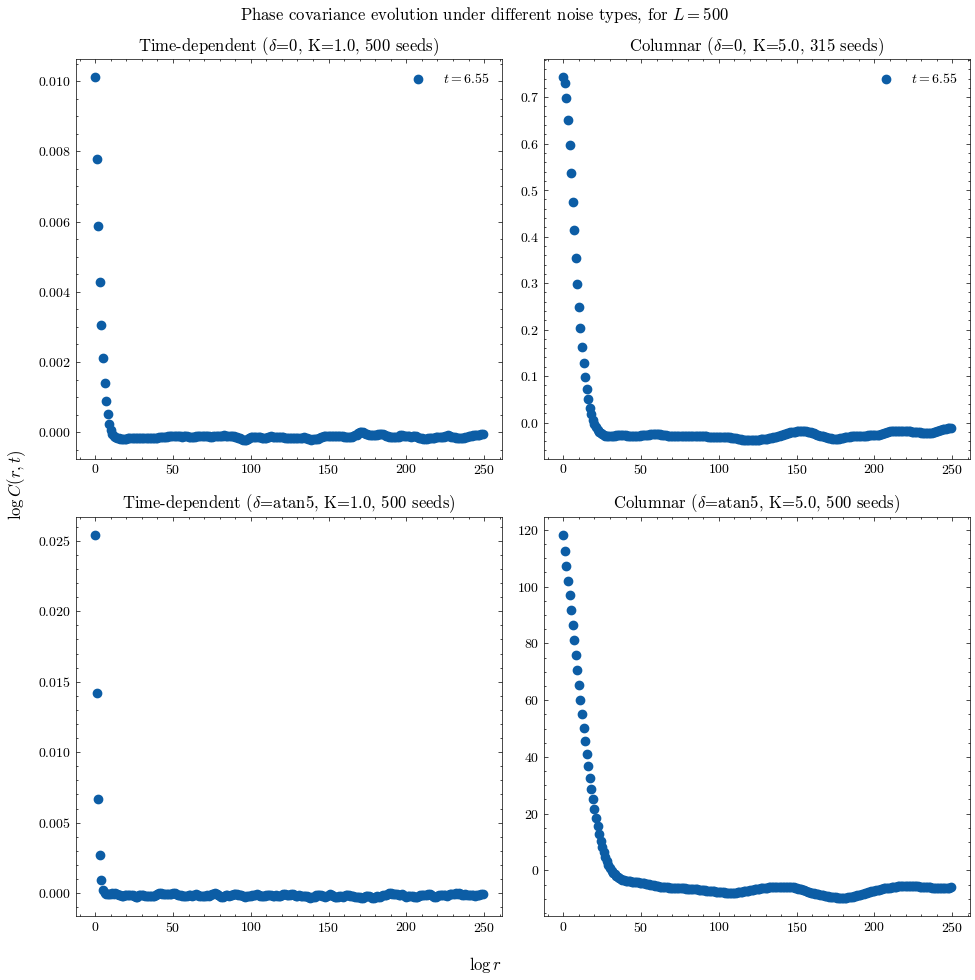

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle("Phase covariance evolution under different noise types, for $L=$" + str(L))

fig.supxlabel(r"$r$")
fig.supylabel(r"$C(r,t)$")

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])
):

    for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["L"] == L)
            & (avg_df["T"] == T)
            & (avg_df["deltaname"] == deltaname)
            & ((avg_df["K"] == 1) | (avg_df["K"] == 20))
        )
        sub = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub.iterrows():
            t = row["t"]            
            mean_phasecovariance = row["mean_phasecovariance"]
            L = row["L"]
            K = row["K"]
            M = row["M"]

            for ti in range(mean_phasecovariance.shape[0])[5:6]:
                rlen = mean_phasecovariance.shape[1] # we plot up to half of this since the system is periodic
                rrange = np.array(range(rlen))
                ax[j,i].scatter(rrange[:int(rlen/2)], mean_phasecovariance[ti,:int(rlen/2)], label=f"$t=${np.round(t[ti],2)}", marker=markerdict[L])
            ax[j,i].set_title(typelabel+ r" ($\delta$="+f"{deltaname}, K={K}, {M} seeds)")

ax[0,0].legend()
ax[0,1].legend()

plt.tight_layout()
plt.show()

### Family-Vicsek collapse of the phase covariance (TO BE DONE)

We need constants $a_1$, $a_2$, which are fit assuming the functional form.

In [19]:
from scipy.special import airy

a_1 = []
for t in range(mean_phasecovariance.shape[0]):
    a_1.append(airy(t**(1/3))[0])  # Airy function value at t^(1/3)

a_2 = 1/100

In [20]:
help(airy)

Help on ufunc:

airy = <ufunc 'airy'>
    airy(x[, out1, out2, out3, out4], / [, out=(None, None, None, None)], *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature])


    airy(z, out=None)

    Airy functions and their derivatives.

    Parameters
    ----------
    z : array_like
        Real or complex argument.
    out : tuple of ndarray, optional
        Optional output arrays for the function values

    Returns
    -------
    Ai, Aip, Bi, Bip : 4-tuple of scalar or ndarray
        Airy functions Ai and Bi, and their derivatives Aip and Bip.

    See Also
    --------
    airye : exponentially scaled Airy functions.

    Notes
    -----
    The Airy functions Ai and Bi are two independent solutions of

    .. math:: y''(x) = x y(x).

    For real `z` in [-10, 10], the computation is carried out by calling
    the Cephes [1]_ `airy` routine, which uses power series summation
    for small `z` and rational minimax approximations for large `z`.

    Ou

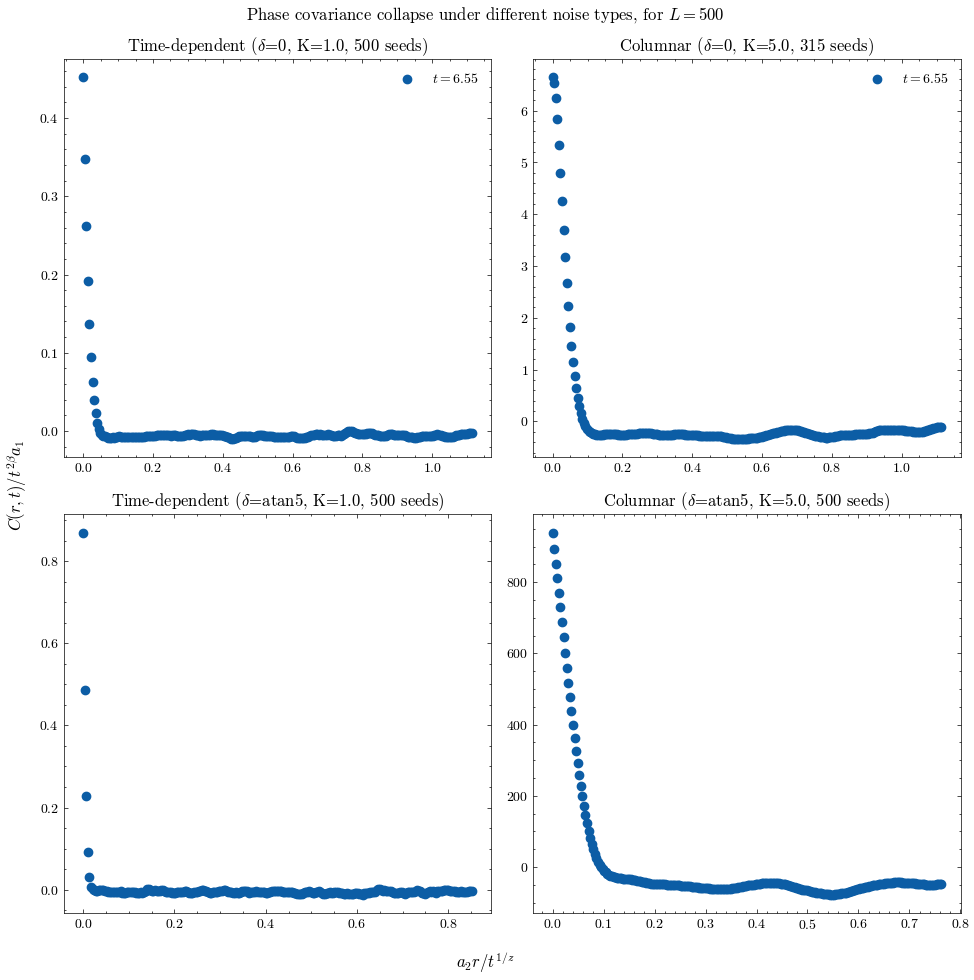

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle("Phase covariance collapse under different noise types, for $L=$" + str(L))

fig.supxlabel(r"$a_2 r/ t^{1/z}$")
fig.supylabel(r"$C(r,t)/ t^{2\beta} a_1$")

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])
):

    for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["L"] == L)
            & (avg_df["T"] == T)
            & (avg_df["deltaname"] == deltaname)
            & ((avg_df["K"] == 1) | (avg_df["K"] == 5))
        )
        sub = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub.iterrows():
            t = row["t"]
            mean_phasecovariance = row["mean_phasecovariance"]
            L = row["L"]
            K = row["K"]
            M = row["M"]

            for ti in range(mean_phasecovariance.shape[0])[5:6]:
                rlen = mean_phasecovariance.shape[1] # we plot up to half of this since the system is periodic
                rrange = np.array(range(rlen))
                ax[j,i].scatter(rrange[:int(rlen/2)] * a_2 / ti**(1/z_dict[typenoise][delta_to_label[deltaname]]),
                                mean_phasecovariance[ti,:int(rlen/2)] / (a_1*ti**(2*beta_dict[typenoise][delta_to_label[deltaname]])),
                                label=f"$t=${np.round(t[ti],2)}", marker=markerdict[L])
            ax[j,i].set_title(typelabel+ r" ($\delta$="+f"{deltaname}, K={K}, {M} seeds)")

ax[0,0].legend()
ax[0,1].legend()

plt.tight_layout()
plt.show()